# TESS Light Curve Filtering and Detrending

This notebook builds on the previous cleaning step (where we applied quality flags and manual outlier removal) to further process the TESS light curves for transit analysis. Our goal is to remove instrumental and astrophysical variability (e.g., stellar activity, pointing drifts) while preserving the transit signal of the target exoplanet. We use robust detrending methods from the `wotan` package, which are designed to handle outliers and missing data.

## Why detrend?
TESS light curves contain systematic trends due to:
- Spacecraft motion and attitude changes
- Focus variations over time
- Pixel‑level sensitivity changes
- Stellar variability (e.g., spots, pulsations)

These trends can mask or distort the transit signal. Detrending fits a smooth model to the out‑of‑transit data and subtracts it, leaving a flattened light curve in which transits are more easily detectable.

## Methods used
We apply two robust detrending algorithms provided by `wotan`:
- **Biweight filtering** (`method='biweight'`): a running median‑like filter that uses a Tukey’s biweight function to downweight outliers. It is robust to outliers and can handle non‑linear trends.
- **Huber spline** (`method='hspline'`): fits a cubic spline with a Huber loss function, which is also robust to outliers. This method is particularly good at capturing slowly varying trends.

Both methods allow us to specify:
- `window_length`: the width (in days) of the smoothing window. Shorter windows capture more rapid variations but may also remove some transit signal; longer windows preserve longer‑term trends.
- `break_tolerance`: determines how often the spline can “break” to follow sharp changes (relevant for `hspline`).

We test several combinations of method and window length and evaluate the performance by computing the standard deviation of the flattened flux **outside the transits** (i.e., using a transit mask derived from the known ephemeris). The lower the scatter, the better the trend removal.

## Transit masking
To ensure we do not fit the transit itself (which would subtract part of the signal), we mask the in‑transit data using the known orbital period, transit duration, and ephemeris of the target planet. These parameters are taken from the literature.

## Output
After testing, we select the combination that gives the lowest out‑of‑transit scatter for each sector and save the flattened light curves (normalized flux) for use in subsequent transit modeling.

In [30]:
import numpy as np
import matplotlib.pyplot as plt 
from astropy.io import fits
import pickle
from wotan import flatten

%matplotlib widget 

In [31]:
# Plot style
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["EB Garamond", "Georgia", "Times New Roman"],
    # ---- Sizes ----
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.labelweight": "light",  # x/y labels
    "font.weight": "light",
    # ---- Axes/ticks style like the PDF ----
    "axes.edgecolor": "0.2",
    "axes.linewidth": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    "axes.grid": False,
    "axes.labelcolor": "0.2",
    "xtick.color": "0.2",
    "ytick.color": "0.2",
    "text.color": "0.2",
})


%matplotlib widget

In [32]:
sector43_dictionary = pickle.load(open('WASP_TESS_sector43_selected.p', 'rb'))
sector44_dictionary = pickle.load(open('WASP_TESS_sector44_selected.p', 'rb'))
sector45_dictionary = pickle.load(open('WASP_TESS_sector45_selected.p', 'rb'))

In [33]:
# Sector 43
time_43 = sector43_dictionary['time']
sap_flux_43 =  sector43_dictionary['sap_flux']
sap_flux_error_43 =  sector43_dictionary['sap_flux_error']
pdcsap_flux_43 =  sector43_dictionary['pdcsap_flux']
pdcsap_flux_error_43 = sector43_dictionary['pdcsap_flux_error']

# Sector 44
time_44 = sector44_dictionary['time']
sap_flux_44 =  sector44_dictionary['sap_flux']
sap_flux_error_44 =  sector44_dictionary['sap_flux_error']
pdcsap_flux_44 =  sector44_dictionary['pdcsap_flux']
pdcsap_flux_error_44 = sector44_dictionary['pdcsap_flux_error']

# Sector 45
time_45 = sector45_dictionary['time']
sap_flux_45 =  sector45_dictionary['sap_flux']
sap_flux_error_45 =  sector45_dictionary['sap_flux_error']
pdcsap_flux_45 =  sector45_dictionary['pdcsap_flux']
pdcsap_flux_error_45 = sector45_dictionary['pdcsap_flux_error'] 

In [34]:
transit_time = 2454508.97824
period = 1.0914199
transit_duration = 2.9959 * 2 / 24.

In [35]:
# Sector 43

phase_folded_time_43 = (time_43-transit_time - period/2)%period - period/2

from wotan import transit_mask
mask_43 = transit_mask(
    time=time_43,
    period = period,
    duration = transit_duration,
    T0=transit_time 
)

# Sector 44

phase_folded_time_44 = (time_44-transit_time - period/2)%period - period/2

from wotan import transit_mask
mask_44 = transit_mask(
    time=time_44,
    period = period,
    duration = transit_duration,
    T0=transit_time 
)


# Sector 45

phase_folded_time_45 = (time_45-transit_time - period/2)%period - period/2

from wotan import transit_mask
mask_45 = transit_mask(
    time=time_45,
    period = period,
    duration = transit_duration,
    T0=transit_time 
)

In [36]:
sap_masked_biweight_w10_flux_43, sap_masked_biweight_w10_model_43 = flatten(
    time_43,
    sap_flux_43,
    method='biweight',
    window_length=1.0, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_43,
)

sap_masked_biweight_w15_flux_43, sap_masked_biweight_w15_model_43 = flatten(
    time_43,
    sap_flux_43,
    method='biweight',
    window_length=1.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_43,
)

sap_masked_hspline_w05_flux_43, sap_masked_hspline_w05_model_43 = flatten(
    time_43,
    sap_flux_43,
    method='hspline',
    window_length=0.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_43,
)

sap_masked_hspline_w10_flux_43, sap_masked_hspline_w10_model_43 = flatten(
    time_43,
    sap_flux_43,
    method='hspline',
    window_length=1.0, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_43,
)

sap_masked_hspline_w15_flux_43, sap_masked_hspline_w15_model_43 = flatten(
    time_43,
    sap_flux_43,
    method='hspline',
    window_length=1.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_43,
)

/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to conv

In [37]:
pdcsap_masked_biweight_w10_flux_43, pdcsap_masked_biweight_w10_model_43 = flatten(
    time_43,
    pdcsap_flux_43,
    method='biweight',
    window_length=1.0, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_43,
)

pdcsap_masked_biweight_w15_flux_43, pdcsap_masked_biweight_w15_model_43 = flatten(
    time_43,
    pdcsap_flux_43,
    method='biweight',
    window_length=1.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_43,
)

pdcsap_masked_hspline_w05_flux_43, pdcsap_masked_hspline_w05_model_43 = flatten(
    time_43,
    pdcsap_flux_43,
    method='hspline',
    window_length=0.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_43,
)

pdcsap_masked_hspline_w10_flux_43, pdcsap_masked_hspline_w10_model_43 = flatten(
    time_43,
    pdcsap_flux_43,
    method='hspline',
    window_length=1.0, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_43,
)

pdcsap_masked_hspline_w15_flux_43, pdcsap_masked_hspline_w15_model_43 = flatten(
    time_43,
    pdcsap_flux_43,
    method='hspline',
    window_length=1.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_43,
)

/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to conv

In [38]:
sap_masked_biweight_w10_flux_44, sap_masked_biweight_w10_model_44 = flatten(
    time_44,
    sap_flux_44,
    method='biweight',
    window_length=1.0, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_44,
)

sap_masked_biweight_w15_flux_44, sap_masked_biweight_w15_model_44 = flatten(
    time_44,
    sap_flux_44,
    method='biweight',
    window_length=1.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_44,
)

sap_masked_hspline_w05_flux_44, sap_masked_hspline_w05_model_44 = flatten(
    time_44,
    sap_flux_44,
    method='hspline',
    window_length=0.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_44,
)

sap_masked_hspline_w10_flux_44, sap_masked_hspline_w10_model_44 = flatten(
    time_44,
    sap_flux_44,
    method='hspline',
    window_length=1.0, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_44,
)

sap_masked_hspline_w15_flux_44, sap_masked_hspline_w15_model_44 = flatten(
    time_44,
    sap_flux_44,
    method='hspline',
    window_length=1.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_44,
)

/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to conv

In [22]:
pdcsap_masked_biweight_w10_flux_44, pdcsap_masked_biweight_w10_model_44 = flatten(
    time_44,
    pdcsap_flux_44,
    method='biweight',
    window_length=1.0, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_44,
)

pdcsap_masked_biweight_w15_flux_44, pdcsap_masked_biweight_w15_model_44 = flatten(
    time_44,
    pdcsap_flux_44,
    method='biweight',
    window_length=1.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_44,
)

pdcsap_masked_hspline_w05_flux_44, pdcsap_masked_hspline_w05_model_44 = flatten(
    time_44,
    pdcsap_flux_44,
    method='hspline',
    window_length=0.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_44,
)

pdcsap_masked_hspline_w10_flux_44, pdcsap_masked_hspline_w10_model_44 = flatten(
    time_44,
    pdcsap_flux_44,
    method='hspline',
    window_length=1.0, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_44,
)

pdcsap_masked_hspline_w15_flux_44, pdcsap_masked_hspline_w15_model_44 = flatten(
    time_44,
    pdcsap_flux_44,
    method='hspline',
    window_length=1.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_44,
)

/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [23]:
sap_masked_biweight_w10_flux_45, sap_masked_biweight_w10_model_45 = flatten(
    time_45,
    sap_flux_45,
    method='biweight',
    window_length=1.0, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_45,
)

sap_masked_biweight_w15_flux_45, sap_masked_biweight_w15_model_45 = flatten(
    time_45,
    sap_flux_45,
    method='biweight',
    window_length=1.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_45,
)

sap_masked_hspline_w05_flux_45, sap_masked_hspline_w05_model_45 = flatten(
    time_45,
    sap_flux_45,
    method='hspline',
    window_length=0.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_45,
)

sap_masked_hspline_w10_flux_45, sap_masked_hspline_w10_model_45 = flatten(
    time_45,
    sap_flux_45,
    method='hspline',
    window_length=1.0, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_45,
)

sap_masked_hspline_w15_flux_45, sap_masked_hspline_w15_model_45 = flatten(
    time_45,
    sap_flux_45,
    method='hspline',
    window_length=1.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_45,
)

/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [24]:
pdcsap_masked_biweight_w10_flux_45, pdcsap_masked_biweight_w10_model_45 = flatten(
    time_45,
    pdcsap_flux_45,
    method='biweight',
    window_length=1.0, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_45,
)

pdcsap_masked_biweight_w15_flux_45, pdcsap_masked_biweight_w15_model_45 = flatten(
    time_45,
    pdcsap_flux_45,
    method='biweight',
    window_length=1.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_45,
)

pdcsap_masked_hspline_w05_flux_45, pdcsap_masked_hspline_w05_model_45 = flatten(
    time_45,
    pdcsap_flux_45,
    method='hspline',
    window_length=0.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_45,
)

pdcsap_masked_hspline_w10_flux_45, pdcsap_masked_hspline_w10_model_45 = flatten(
    time_45,
    pdcsap_flux_45,
    method='hspline',
    window_length=1.0, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_45,
)

pdcsap_masked_hspline_w15_flux_45, pdcsap_masked_hspline_w15_model_45 = flatten(
    time_45,
    pdcsap_flux_45,
    method='hspline',
    window_length=1.5, 
    break_tolerance=0.5, 
    return_trend = True,
    mask = mask_45,
)

/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/ashaimaalrawhi/.pyenv/versions/3.10.0/lib/python3.10/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to conv

In [25]:
print('Sector 43')
print('STD SAP biweight, window=1.0   : {0:.6f}'.format(np.std(sap_masked_biweight_w10_flux_43[~mask_43])))
print('STD SAP biweight, window=1.5   : {0:.6f}'.format(np.std(sap_masked_biweight_w15_flux_43[~mask_43])))
print('STD SAP hspline, window=0.5    : {0:.6f}'.format(np.std(sap_masked_hspline_w05_flux_43[~mask_43])))
print('STD SAP hspline, window=1.0    : {0:.6f}'.format(np.std(sap_masked_hspline_w10_flux_43[~mask_43])))
print('STD SAP hspline, window=1.5    : {0:.6f}'.format(np.std(sap_masked_hspline_w15_flux_43[~mask_43])))
print('STD PDCSAP biweight, window=1.0: {0:.6f}'.format(np.std(pdcsap_masked_biweight_w10_flux_43[~mask_43])))
print('STD PDCSAP biweight, window=1.5: {0:.6f}'.format(np.std(pdcsap_masked_biweight_w15_flux_43[~mask_43])))
print('STD PDCSAP hspline, window=0.5 : {0:.6f}'.format(np.std(pdcsap_masked_hspline_w05_flux_43[~mask_43])))
print('STD PDCSAP hspline, window=1.0 : {0:.6f}'.format(np.std(pdcsap_masked_hspline_w10_flux_43[~mask_43])))
print('STD PDCSAP hspline, window=1.5 : {0:.6f}'.format(np.std(pdcsap_masked_hspline_w15_flux_43[~mask_43])))
print('------------')
print('Sector 44')
print('STD SAP biweight, window=1.0   : {0:.6f}'.format(np.std(sap_masked_biweight_w10_flux_44[~mask_44])))
print('STD SAP biweight, window=1.5   : {0:.6f}'.format(np.std(sap_masked_biweight_w15_flux_44[~mask_44])))
print('STD SAP hspline, window=0.5    : {0:.6f}'.format(np.std(sap_masked_hspline_w05_flux_44[~mask_44])))
print('STD SAP hspline, window=1.0    : {0:.6f}'.format(np.std(sap_masked_hspline_w10_flux_44[~mask_44])))
print('STD SAP hspline, window=1.5    : {0:.6f}'.format(np.std(sap_masked_hspline_w15_flux_44[~mask_44])))
print('STD PDCSAP biweight, window=1.0: {0:.6f}'.format(np.std(pdcsap_masked_biweight_w10_flux_44[~mask_44])))
print('STD PDCSAP biweight, window=1.5: {0:.6f}'.format(np.std(pdcsap_masked_biweight_w15_flux_44[~mask_44])))
print('STD PDCSAP hspline, window=0.5 : {0:.6f}'.format(np.std(pdcsap_masked_hspline_w05_flux_44[~mask_44])))
print('STD PDCSAP hspline, window=1.0 : {0:.6f}'.format(np.std(pdcsap_masked_hspline_w10_flux_44[~mask_44])))
print('STD PDCSAP hspline, window=1.5 : {0:.6f}'.format(np.std(pdcsap_masked_hspline_w15_flux_44[~mask_44])))
print('------------')
print('Sector 45')
print('STD SAP biweight, window=1.0   : {0:.6f}'.format(np.std(sap_masked_biweight_w10_flux_45[~mask_45])))
print('STD SAP biweight, window=1.5   : {0:.6f}'.format(np.std(sap_masked_biweight_w15_flux_45[~mask_45])))
print('STD SAP hspline, window=0.5    : {0:.6f}'.format(np.std(sap_masked_hspline_w05_flux_45[~mask_45])))
print('STD SAP hspline, window=1.0    : {0:.6f}'.format(np.std(sap_masked_hspline_w10_flux_45[~mask_45])))
print('STD SAP hspline, window=1.5    : {0:.6f}'.format(np.std(sap_masked_hspline_w15_flux_45[~mask_45])))
print('STD PDCSAP biweight, window=1.0: {0:.6f}'.format(np.std(pdcsap_masked_biweight_w10_flux_45[~mask_45])))
print('STD PDCSAP biweight, window=1.5: {0:.6f}'.format(np.std(pdcsap_masked_biweight_w15_flux_45[~mask_45])))
print('STD PDCSAP hspline, window=0.5 : {0:.6f}'.format(np.std(pdcsap_masked_hspline_w05_flux_45[~mask_45])))
print('STD PDCSAP hspline, window=1.0 : {0:.6f}'.format(np.std(pdcsap_masked_hspline_w10_flux_45[~mask_45])))
print('STD PDCSAP hspline, window=1.5 : {0:.6f}'.format(np.std(pdcsap_masked_hspline_w15_flux_45[~mask_45])))
print('------------')

Sector 43
STD SAP biweight, window=1.0   : 0.001917
STD SAP biweight, window=1.5   : 0.001919
STD SAP hspline, window=0.5    : 0.001914
STD SAP hspline, window=1.0    : 0.001917
STD SAP hspline, window=1.5    : 0.001920
STD PDCSAP biweight, window=1.0: 0.001884
STD PDCSAP biweight, window=1.5: 0.001886
STD PDCSAP hspline, window=0.5 : 0.001882
STD PDCSAP hspline, window=1.0 : 0.001884
STD PDCSAP hspline, window=1.5 : 0.001884
------------
Sector 44
STD SAP biweight, window=1.0   : 0.001882
STD SAP biweight, window=1.5   : 0.001884
STD SAP hspline, window=0.5    : 0.001879
STD SAP hspline, window=1.0    : 0.001881
STD SAP hspline, window=1.5    : 0.001883
STD PDCSAP biweight, window=1.0: 0.001893
STD PDCSAP biweight, window=1.5: 0.001896
STD PDCSAP hspline, window=0.5 : 0.001890
STD PDCSAP hspline, window=1.0 : 0.001893
STD PDCSAP hspline, window=1.5 : 0.001896
------------
Sector 45
STD SAP biweight, window=1.0   : 0.001835
STD SAP biweight, window=1.5   : 0.001837
STD SAP hspline, win

In [26]:
print('average normalized error: {0:.6f}'.format(np.average(pdcsap_flux_error_43[~mask_43]/pdcsap_masked_biweight_w10_model_43[~mask_43])))

average normalized error: 0.001574


In [27]:
# Sector 43: STD PDCSAP hspline, window=1.0 : 0.001883
# Sector 44: STD SAP hspline, window=1.0    : 0.001882
# Sector 45: STD SAP hspline, window=1.0    : 0.001835


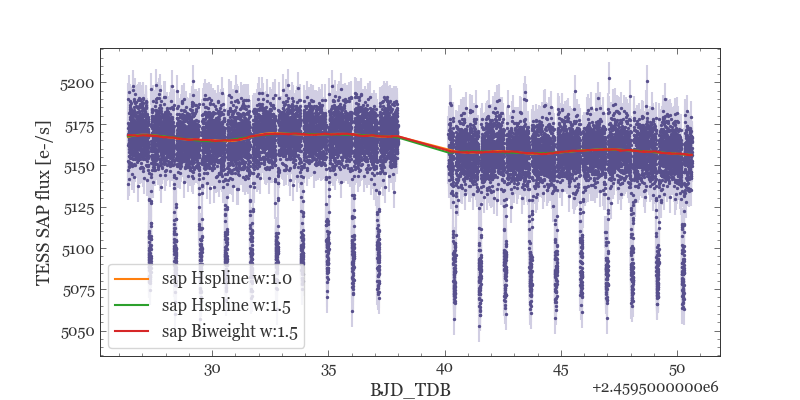

In [28]:
plt.figure(figsize=(8,4))
plt.scatter(time_45, sap_flux_45, c='#58508d', s=2)
plt.errorbar(time_45, sap_flux_45, yerr=sap_flux_error_45, ecolor='#d1cee3', fmt=' ', zorder=-1)
plt.plot(time_45, sap_masked_hspline_w10_model_45, zorder=10, label='sap Hspline w:1.0')
plt.plot(time_45, sap_masked_hspline_w15_model_45, zorder=10, label='sap Hspline w:1.5')
plt.plot(time_45, sap_masked_biweight_w15_model_45, zorder=10, label='sap Biweight w:1.5')

#plt.plot(time, sap_masked_flatten_model, c='#ffa600', zorder=11, label='Hspline w:0.5')
#plt.plot(time, sap_masked_biweight_w10_model, c='C3', zorder=11, label='Biweight w:1.0')
plt.xlabel('BJD_TDB')
plt.ylabel('TESS SAP flux [e-/s]')
plt.legend()
plt.show()

In [29]:
import pickle 

sector43_dictionary = {
    'time': time_43,
    'selected_flux': pdcsap_masked_hspline_w10_flux_43,
    'selected_flux_error': pdcsap_masked_hspline_w10_flux_43/pdcsap_masked_hspline_w10_model_43,
    'sap_masked_hspline_w10_flux': sap_masked_hspline_w10_flux_43,
    'sap_masked_hspline_w10_flux_error': sap_masked_hspline_w10_flux_43/sap_masked_hspline_w10_model_43,
    'sap_masked_hspline_w15_flux': sap_masked_hspline_w15_flux_43,
    'sap_masked_hspline_w15_flux_error': sap_masked_hspline_w15_flux_43/sap_masked_hspline_w15_model_43,
    'pdcsap_masked_hspline_w10_flux': sap_masked_hspline_w10_flux_43,
    'pdcsap_masked_hspline_w10_flux_error': sap_masked_hspline_w10_flux_43/sap_masked_hspline_w10_model_43,
    'pdcsap_masked_hspline_w15_flux': sap_masked_hspline_w15_flux_43,
    'pdcsap_masked_hspline_w15_flux_error': sap_masked_hspline_w15_flux_43/sap_masked_hspline_w15_model_43,
}

pickle.dump(sector43_dictionary, 
            open('WASP_TESS_sector43_filter_selected.p','wb'))


sector44_dictionary = {
    'time': time_44,
    'selected_flux': sap_masked_hspline_w10_flux_44,
    'selected_flux_error': sap_masked_hspline_w10_flux_44/sap_masked_hspline_w10_model_44,
    'sap_masked_hspline_w10_flux': sap_masked_hspline_w10_flux_44,
    'sap_masked_hspline_w10_flux_error': sap_masked_hspline_w10_flux_44/sap_masked_hspline_w10_model_44,
    'sap_masked_hspline_w15_flux': sap_masked_hspline_w15_flux_44,
    'sap_masked_hspline_w15_flux_error': sap_masked_hspline_w15_flux_44/sap_masked_hspline_w15_model_44,
    'pdcsap_masked_hspline_w10_flux': sap_masked_hspline_w10_flux_44,
    'pdcsap_masked_hspline_w10_flux_error': sap_masked_hspline_w10_flux_44/sap_masked_hspline_w10_model_44,
    'pdcsap_masked_hspline_w15_flux': sap_masked_hspline_w15_flux_44,
    'pdcsap_masked_hspline_w15_flux_error': sap_masked_hspline_w15_flux_44/sap_masked_hspline_w15_model_44,
}

pickle.dump(sector44_dictionary, 
            open('WASP_TESS_sector44_filter_selected.p','wb'))



sector45_dictionary = {
    'time': time_45,
    'selected_flux': sap_masked_hspline_w10_flux_45,
    'selected_flux_error': sap_masked_hspline_w10_flux_45/sap_masked_hspline_w10_model_45,
    'sap_masked_hspline_w10_flux': sap_masked_hspline_w10_flux_45,
    'sap_masked_hspline_w10_flux_error': sap_masked_hspline_w10_flux_45/sap_masked_hspline_w10_model_45,
    'sap_masked_hspline_w15_flux': sap_masked_hspline_w15_flux_45,
    'sap_masked_hspline_w15_flux_error': sap_masked_hspline_w15_flux_45/sap_masked_hspline_w15_model_45,
    'pdcsap_masked_hspline_w10_flux': sap_masked_hspline_w10_flux_45,
    'pdcsap_masked_hspline_w10_flux_error': sap_masked_hspline_w10_flux_45/sap_masked_hspline_w10_model_45,
    'pdcsap_masked_hspline_w15_flux': sap_masked_hspline_w15_flux_45,
    'pdcsap_masked_hspline_w15_flux_error': sap_masked_hspline_w15_flux_45/sap_masked_hspline_w15_model_45,
}

pickle.dump(sector45_dictionary, 
            open('WASP_TESS_sector45_filter_selected.p','wb'))